# 02 — Missed-visit risk model

Predict whether a scheduled follow-up visit will be missed, using only what is known when the visit is booked.
Compare a transparent rule score, logistic regression and gradient boosting; pick the simplest model within a small margin;
check calibration and the operational metric that matters (precision at worklist capacity); handle new patients with partial pooling.

Everything here calls the same code that the API and the nightly job use (`ml/features.py`, `ml/cold_start.py`, `ml/train.py`).

In [1]:
import sys, warnings, json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
ROOT = Path.cwd().resolve(); ROOT = ROOT if (ROOT / "D_Clinic_Backend").exists() else ROOT.parent
sys.path.insert(0, str(ROOT / "D_Clinic_Backend"))
from app.db import engine
from ml.features import load_tables_from_db, build_feature_table, FEATURES
from ml.train import (make_splits, fit_all, evaluate, precision_at_capacity, calibration_table, fairness_table,
                      explain_rows, oracle_ceiling, MODEL_FEATURES, CAPACITY_SHARE)
from ml.cold_start import add_pooled_feature
plt.rcParams["figure.figsize"] = (9, 3.5)
AS_OF = pd.Timestamp("2026-09-26")
tables = load_tables_from_db(engine)
ft = build_feature_table(tables, AS_OF)
splits = make_splits(ft)
res = fit_all(splits)
te, p = res["frames"]["test"], res["preds"]["test"][res["chosen"]]
print("chosen:", res["chosen"], {k: len(v) for k, v in splits.items()})

chosen: logistic {'train': 13422, 'valid': 977, 'test': 2028}


## 1. Label and splits

Strict split: patients hashed into pools **and** a time cut, so no patient is in two splits and no future information reaches training rows.

In [2]:
pd.DataFrame({k: {"rows": len(v), "patients": v.patient_id.nunique(), "missed_rate": round(v.missed.mean(), 3),
                  "from": pd.to_datetime(v.scheduled_date).min().date(), "to": pd.to_datetime(v.scheduled_date).max().date()}
              for k, v in splits.items()}).T

,rows,patients,missed_rate,from,to
train,13422,2588,0.281,2024-09-17,2026-02-28
valid,977,506,0.276,2026-03-01,2026-05-31
test,2028,922,0.295,2026-06-01,2026-09-25


## 2. Models and metrics

In [3]:
rows = []
for split in ["valid", "test"]:
    for m in ["rules", "logistic", "boosting"]:
        r = res["metrics"][split][m]
        rows.append({"split": split, "model": m, "n": r["n"], "AUC": r["auc"], "PR-AUC": r["pr_auc"], "Brier": r.get("brier"),
                     "ECE": r.get("ece"), f"precision@{CAPACITY_SHARE:.0%}": r["cap_precision_at_k"], "lift": r["cap_lift"]})
pd.DataFrame(rows).round(3)

,split,model,n,AUC,PR-AUC,Brier,ECE,precision@30%,lift
0,valid,rules,977,0.633,0.358,NaN,NaN,0.380,1.374
1,valid,logistic,977,0.666,0.418,0.188,0.040,0.398,1.441
2,valid,boosting,977,0.662,0.428,0.187,0.032,0.414,1.497
3,test,rules,2028,0.626,0.401,NaN,NaN,0.421,1.427
4,test,logistic,2028,0.648,0.459,0.194,0.022,0.438,1.485
5,test,boosting,2028,0.649,0.462,0.194,0.018,0.433,1.469


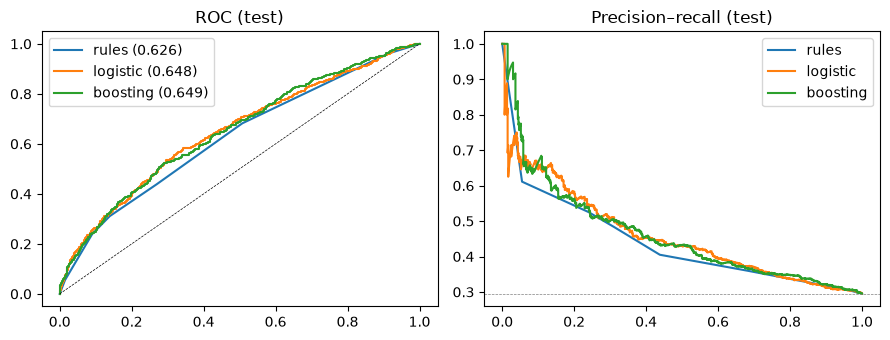

In [4]:
from sklearn.metrics import roc_curve, precision_recall_curve
y = te.missed.astype(int).values
fig, ax = plt.subplots(1, 2)
for m in ["rules", "logistic", "boosting"]:
    s = res["preds"]["test"][m]
    fpr, tpr, _ = roc_curve(y, s); ax[0].plot(fpr, tpr, label=f"{m} ({res['metrics']['test'][m]['auc']:.3f})")
    pr, rc, _ = precision_recall_curve(y, s); ax[1].plot(rc, pr, label=m)
ax[0].plot([0, 1], [0, 1], "k--", lw=.5); ax[0].set_title("ROC (test)"); ax[0].legend()
ax[1].axhline(y.mean(), ls="--", c="grey", lw=.5); ax[1].set_title("Precision–recall (test)"); ax[1].legend()
plt.tight_layout()

## 3. Signal ceiling

The synthetic generator has a hidden per-patient propensity. Scoring with it tells us the best any model could do — the rest is irreducible per-visit randomness.

In [5]:
ceiling = oracle_ceiling(te, ROOT / "data/synth/out/_truth_patients.csv")
pd.Series({**ceiling, "selected_model_auc": res["metrics"]["test"][res["chosen"]]["auc"]}).round(3).to_frame("AUC")

,AUC
theta_only_auc,0.681
theta_plus_known_effects_auc,0.704
selected_model_auc,0.648


## 4. Precision at worklist capacity

A facility can only call so many people. Within each facility-week we rank by score and take the top share; how many of those were actually missed?

,rules,logistic,boosting
10%,0.523,0.540,0.519
20%,0.459,0.463,0.477
30%,0.421,0.438,0.433
40%,0.389,0.400,0.397
50%,0.362,0.376,0.371


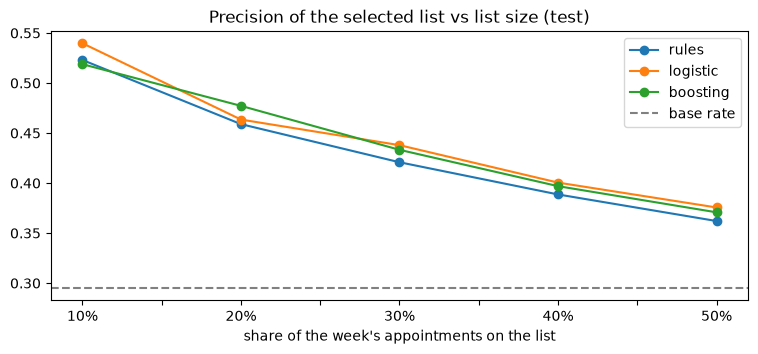

In [6]:
shares = [0.1, 0.2, 0.3, 0.4, 0.5]
tab = pd.DataFrame({m: [precision_at_capacity(te, res["preds"]["test"][m], s)["precision_at_k"] for s in shares]
                    for m in ["rules", "logistic", "boosting"]}, index=[f"{s:.0%}" for s in shares])
ax = tab.plot(marker="o", title="Precision of the selected list vs list size (test)")
ax.axhline(y.mean(), ls="--", c="grey", label="base rate"); ax.set_xlabel("share of the week's appointments on the list"); ax.legend()
tab.round(3)

## 5. Calibration and risk bands

,n,observed_miss_rate
band,,
low,827,0.201
medium,714,0.293
high,487,0.458


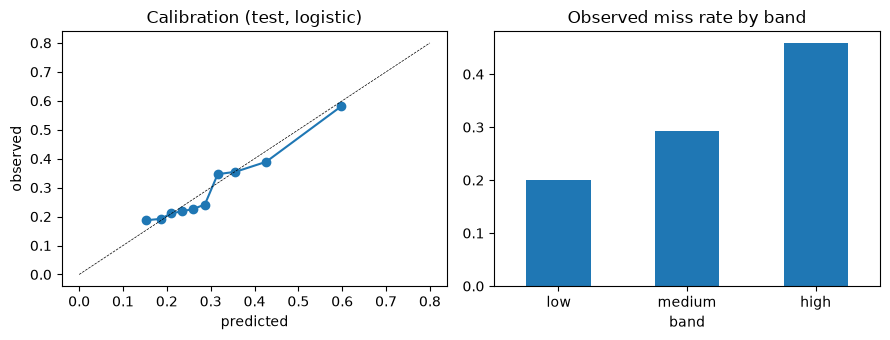

In [7]:
ct = calibration_table(y, p)
fig, ax = plt.subplots(1, 2)
ax[0].plot(ct.predicted, ct.observed, marker="o"); ax[0].plot([0, .8], [0, .8], "k--", lw=.5)
ax[0].set_xlabel("predicted"); ax[0].set_ylabel("observed"); ax[0].set_title(f"Calibration (test, {res['chosen']})")
from ml.train import band
b = pd.DataFrame({"band": band(p, res["thresholds"]), "missed": y}).groupby("band").missed.agg(["size", "mean"]).reindex(["low", "medium", "high"])
b["mean"].plot.bar(ax=ax[1], rot=0, title="Observed miss rate by band"); plt.tight_layout()
b.rename(columns={"size": "n", "mean": "observed_miss_rate"}).round(3)

## 6. What drives the score

Standardised logistic coefficients. Positive = raises missed-visit risk.

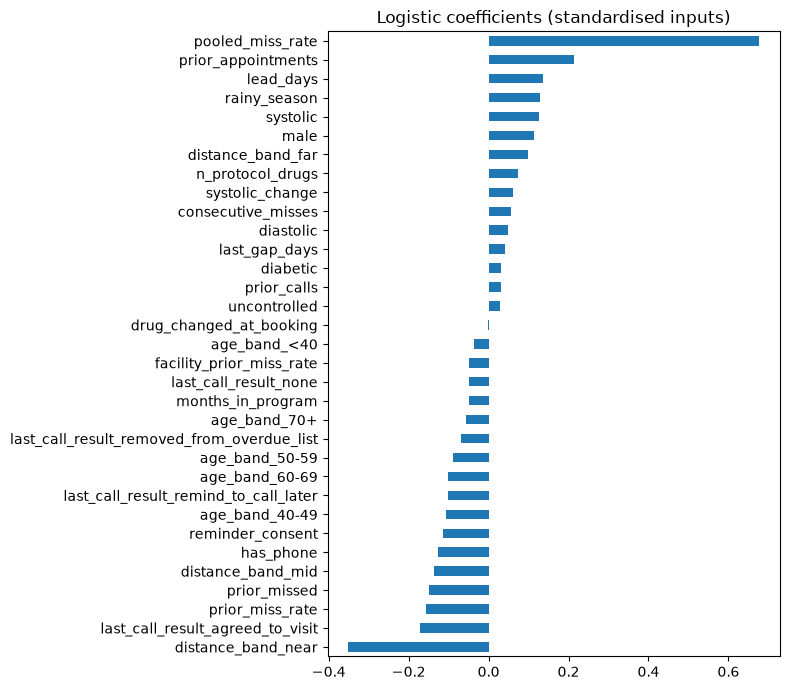

In [8]:
lr = res["logistic"]; prep = lr.named_steps["prep"]
names = [n.split("__", 1)[1] for n in prep.get_feature_names_out()]
coef = pd.Series(lr.named_steps["clf"].coef_[0], index=names)
coef = coef[~coef.index.str.startswith(("facility_id_", "scheduled_weekday_"))].sort_values()
coef.plot.barh(figsize=(8, 7), title="Logistic coefficients (standardised inputs)"); plt.tight_layout()

## 7. New patients: partial pooling

Rows with no personal history get the group estimate; the UI labels them as such.

In [9]:
pooled = res["cold_start"].pooled(te)
cs = pd.DataFrame({"basis": pooled.basis, "group_level": pooled.group_level, "observed": y, "predicted": p})
display(cs.groupby("basis").agg(n=("observed", "size"), observed=("observed", "mean"), predicted=("predicted", "mean")).round(3))
cs[cs.basis == "group"].group_level.value_counts().to_frame("group rows by back-off level")

,n,observed,predicted
basis,,,
group,239,0.280,0.289
mixed,769,0.307,0.293
personal,1020,0.289,0.313


,group rows by back-off level
group_level,
facility_id × diabetic × n_protocol_drugs × age_band,236
facility_id × age_band,3


## 8. Example explanations

In [10]:
f = add_pooled_feature(te, res["cold_start"])
ex = pd.DataFrame({"p": p.round(3), "basis": pooled.basis, "reasons": explain_rows(res["logistic"], f)})
ex.sort_values("p", ascending=False).head(8)

,p,basis,reasons
1193,0.902,personal,[high estimated miss rate (own history and sim...
1321,0.864,personal,[high estimated miss rate (own history and sim...
1474,0.825,mixed,[high estimated miss rate (own history and sim...
460,0.823,personal,[high estimated miss rate (own history and sim...
686,0.818,personal,[high estimated miss rate (own history and sim...
1645,0.816,mixed,[high estimated miss rate (own history and sim...
1179,0.812,personal,[high estimated miss rate (own history and sim...
1743,0.798,mixed,[high estimated miss rate (own history and sim...


## Takeaways

- Logistic regression is kept: boosting gains < 0.01 AUC, and a linear model gives readable reasons.
- At 30% list capacity the model reaches ~0.44 precision vs a 0.30 base rate (lift ≈ 1.5) and beats the hand rules.
- The model sits ~0.05 AUC below the synthetic ceiling; the remaining gap is per-visit randomness, not a missing feature.
- Calibration is good enough to show bands; a raw percentage is still hidden from the UI until validated on real data.
- Cold-start rows are well calibrated as a group estimate and labelled as such.